<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW2_PT1_322512690_212393532.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2**  - Deep Learning Winter 2024

#  Classification using Conventional Neural Network

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



# **Part 1 : CNN on CIFAR-10**

In this part , we will design , implement , and experiment with the Convolutional Neural Networks (CNNs) on the CIFAR-10 dataset in different ways and compare the performance of each network on image classification.

In [1]:
# Import Libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F  # Functional API
import random

## **Loading  and Pre-processing the data :**

*   First step : we start by loading the CIFAR-10 dataset from the torchvision library.
*   Second step : we split the training dataset into : 80% for training set and 20% for validation set .

*   Third step: we create data loaders for each of the training, validation and testing datasets.


In [2]:
# Step 1: Load CIFAR-10 dataset with transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize RGB channels
])

# Load training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Step 2: Split the training dataset into training and validation sets
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # 20% for validation

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Step 3: Create Data Loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)




100%|██████████| 170M/170M [00:03<00:00, 47.3MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


## **Visualization Data Examples:**

we will visualize some data examples from differnt classes from the trining set :


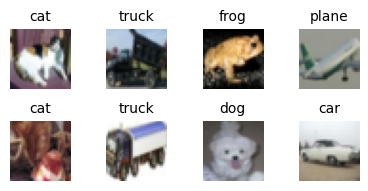

In [3]:
#Define a function to display images
def imshow(img,title=None):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


# CIFAR-10 class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Display sample images from the training set
def show_sample_images(loader, num_images=8):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    cols=min(num_images,4)
    rows=(num_images+cols -1)//cols

    fig,axes=plt.subplots(rows,cols,figsize=(cols,rows))
    axes=axes.flatten()

    for i in range(num_images):
      ax=axes[i]
      img=imshow(images[i])
      ax.imshow(img)
      ax.set_title(classes[labels[i]],fontsize=10) # add class label above each image
      ax.axis('off')


    plt.tight_layout()
    plt.show()



# Visualize some samples from the training set
show_sample_images(train_loader)

# **TASK 1 :**

In this task we will create a simple CNN with 2 convlutional layers with 1 fully connected layer with softmax output to use for image classification .

## **Define the architecture:**


*   **convlutional layers**:

1.   **Conv Layer 1 :**<br>
input : 3 channels (RGB image).<br>
output : 16 filters (feature maps).<br>
Kernel size : 3x3 kernels. <br>
Stride : 1.<br>
padding : 1.<br>
2.   **Conv Layer 2 :**<br>
input : 16 channels ( from conv1).<br>
output : 32 filters (feature maps).<br>
Kernel size : 3x3 kernels. <br>
Stride : 1.<br>
padding : 1.<br>


*   **Activation function :** ReLu for both convlutional layers.



*   **Pooling Layers:  :** Max Pooling layer after each ReLU-activated convlutional layer.


*   **Fully Connected Layer :**<br>
 the final layer is a fully connected layer:
input : 32 x 8 x 8 = 2048 ( flattened feature maps from conv2) <br>
output : 10  ( one output for each CIFAR- 10 class).<br>






**Here's an image that describe the full  architecture we used for this task step by step:**


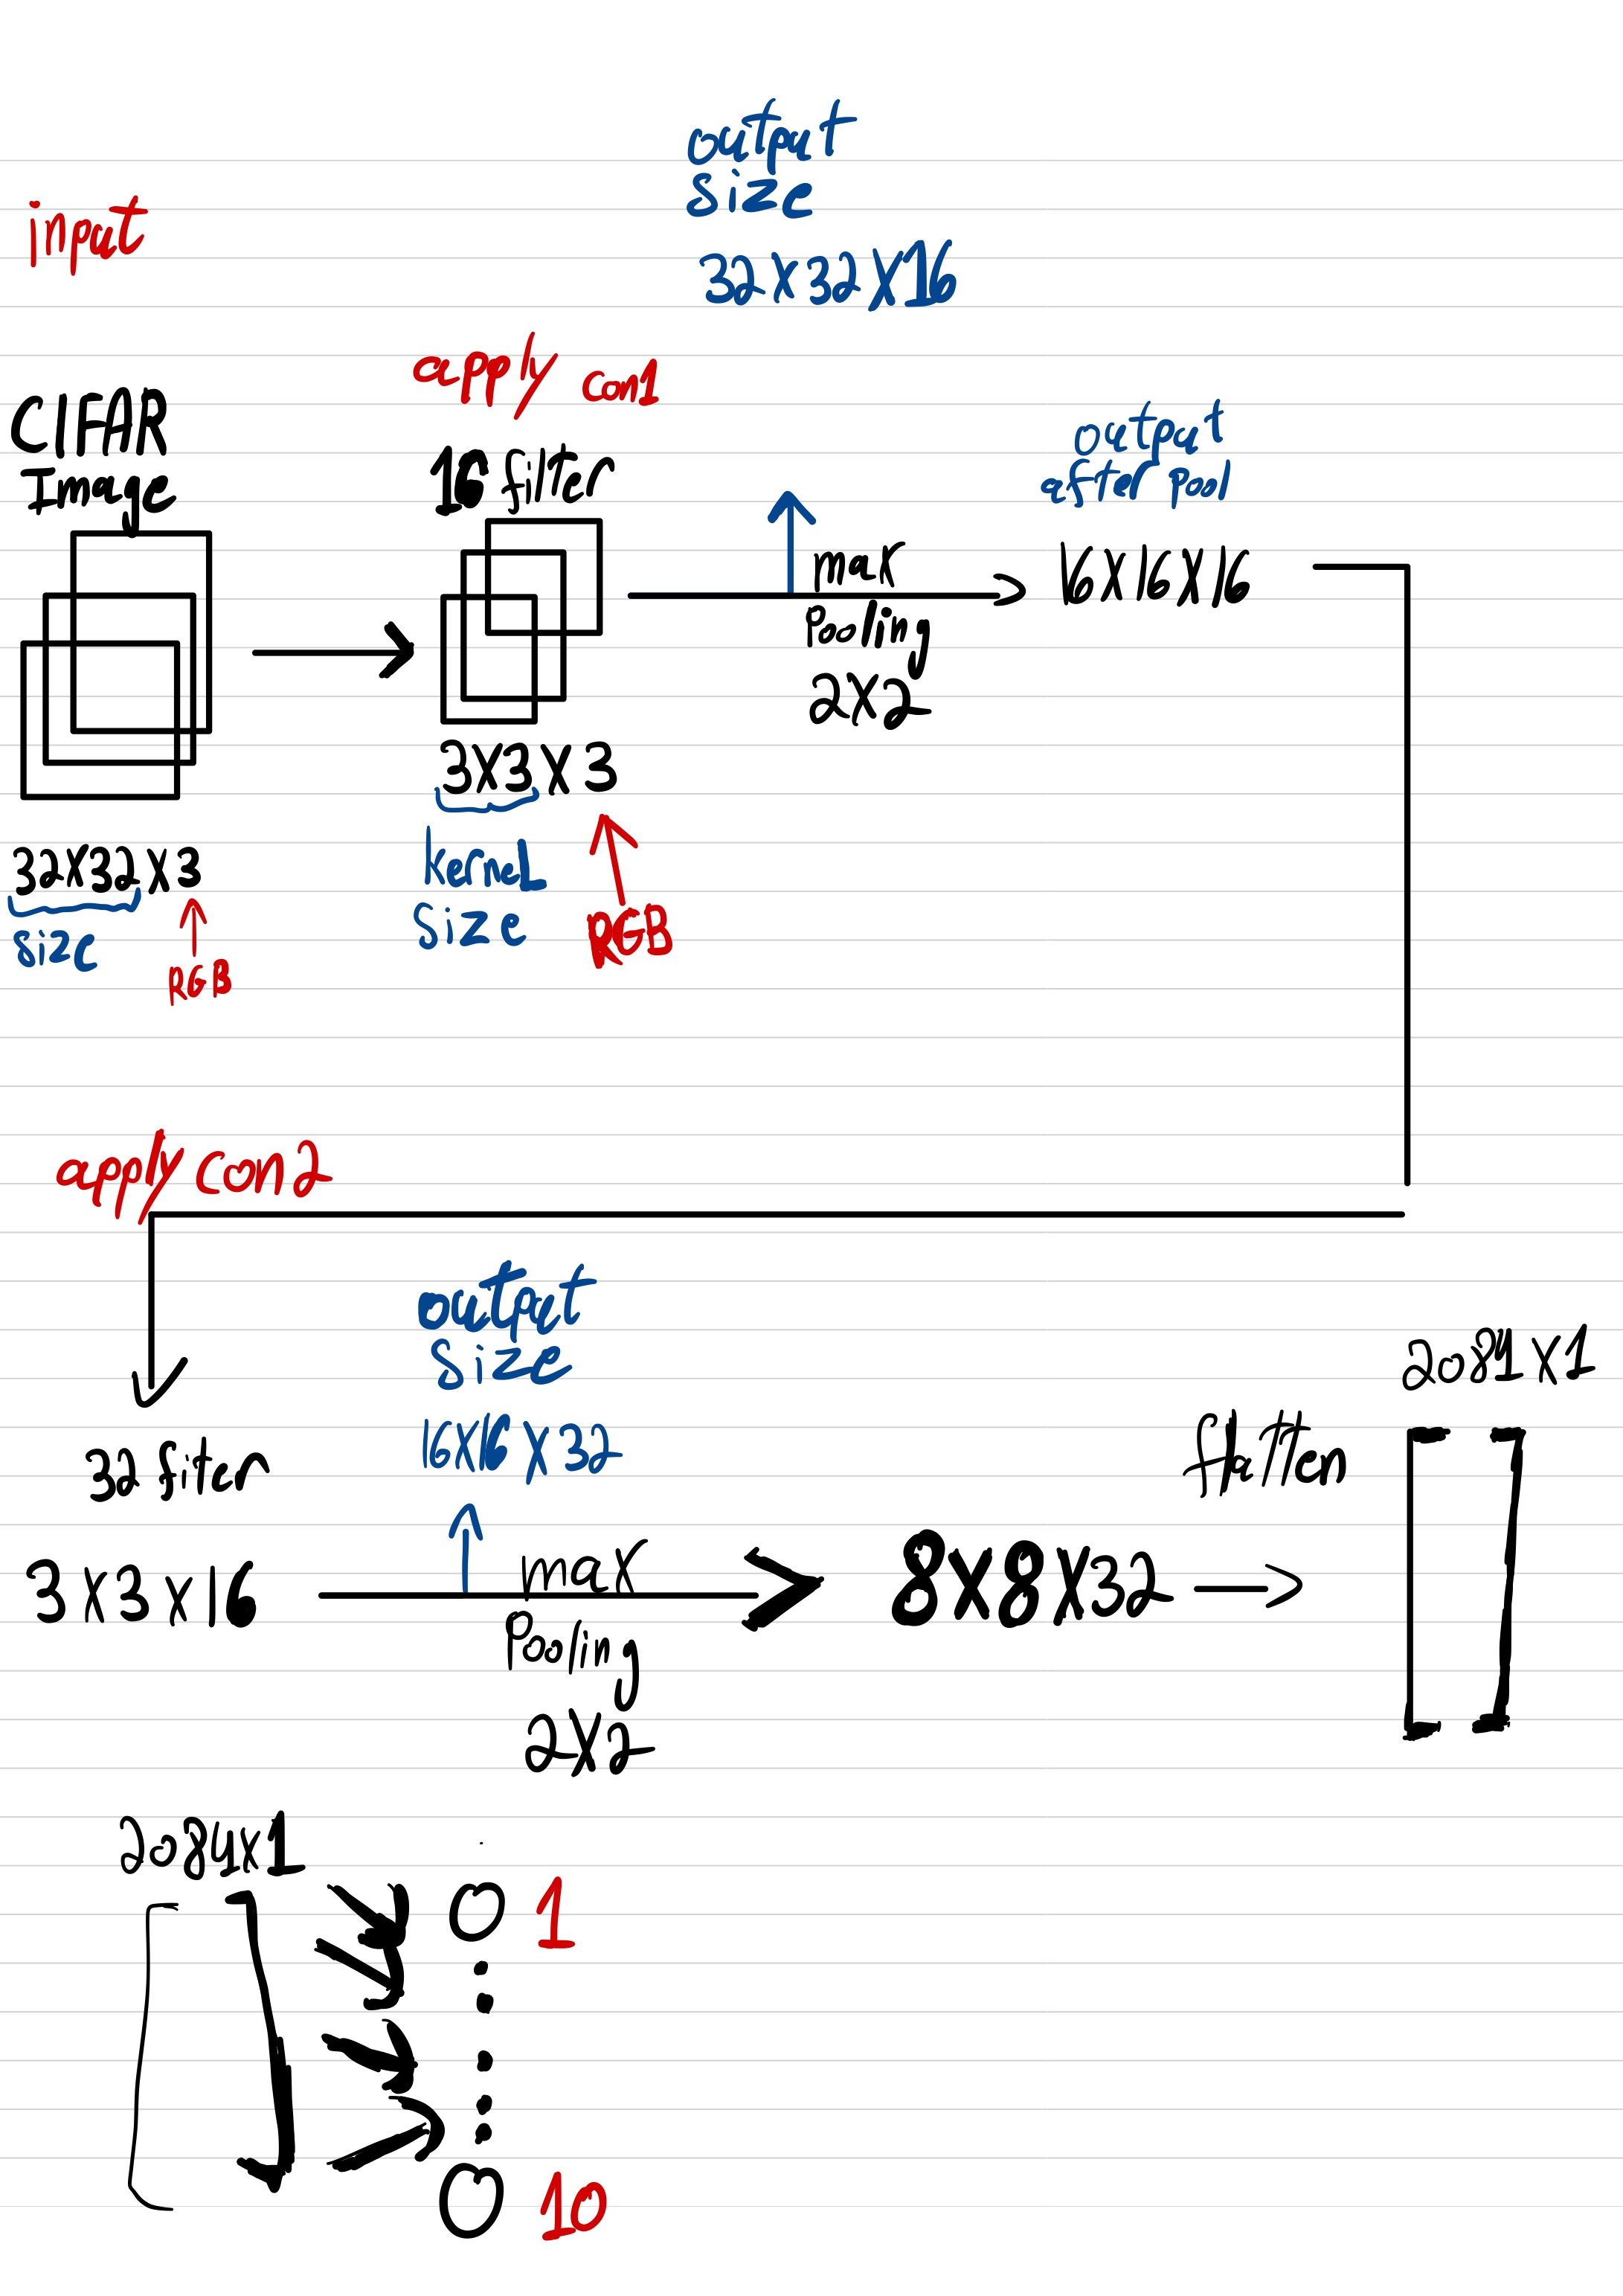

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)  # CIFAR-10 has 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


## **Training the Network:**

we will train the netwrok we build for 10 epochs with the next parameters:


1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:10.<br>
      Batch Size: 64.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.


In [5]:
def train_and_validate(net, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    best_val_accuracy = 0.0
    best_model_state = None

   # Lists to store the losses and accuracies
    train_acc=[]
    train_loss=[]
    val_acc=[]
    val_loss=[]

    for epoch in range(num_epochs):
        # Training phase
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_loss= running_loss/ len(train_loader)
        train_loss.append(epoch_loss)
        train_acc.append(train_accuracy)

        # Validation phase
        net.eval()
        val_running_loss=0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for data in val_loader:
                inputs, labels = data

                outputs = net(inputs)
                loss=criterion(outputs,labels)
                val_running_loss+=loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        epoch_val_loss=val_running_loss / len(val_loader)
        val_loss.append(epoch_val_loss)
        val_acc.append(val_accuracy)

        # Save the best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = net.state_dict()

        print(f'Epoch {epoch + 1}/{num_epochs} Loss: {running_loss / len(train_loader):.3f} Train Accuracy: {train_accuracy:.2f}% Validation Accuracy: {val_accuracy:.2f}%')

    print('Finished Training')
    net.load_state_dict(best_model_state)
    return net , train_loss , train_acc , val_loss , val_acc


In [6]:
net = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)
num_epochs=10


net , train_loss , train_acc , val_loss , val_acc = train_and_validate(net, criterion, optimizer, train_loader, val_loader)

Epoch 1/10 Loss: 1.481 Train Accuracy: 47.62% Validation Accuracy: 55.51%
Epoch 2/10 Loss: 1.168 Train Accuracy: 59.22% Validation Accuracy: 60.88%
Epoch 3/10 Loss: 1.046 Train Accuracy: 63.74% Validation Accuracy: 62.86%
Epoch 4/10 Loss: 0.969 Train Accuracy: 66.58% Validation Accuracy: 63.88%
Epoch 5/10 Loss: 0.911 Train Accuracy: 68.52% Validation Accuracy: 65.44%
Epoch 6/10 Loss: 0.871 Train Accuracy: 70.12% Validation Accuracy: 64.06%
Epoch 7/10 Loss: 0.834 Train Accuracy: 71.15% Validation Accuracy: 65.58%
Epoch 8/10 Loss: 0.805 Train Accuracy: 72.30% Validation Accuracy: 66.37%
Epoch 9/10 Loss: 0.776 Train Accuracy: 73.15% Validation Accuracy: 67.18%
Epoch 10/10 Loss: 0.754 Train Accuracy: 73.93% Validation Accuracy: 67.22%
Finished Training


# Plot the losses and accuracy :



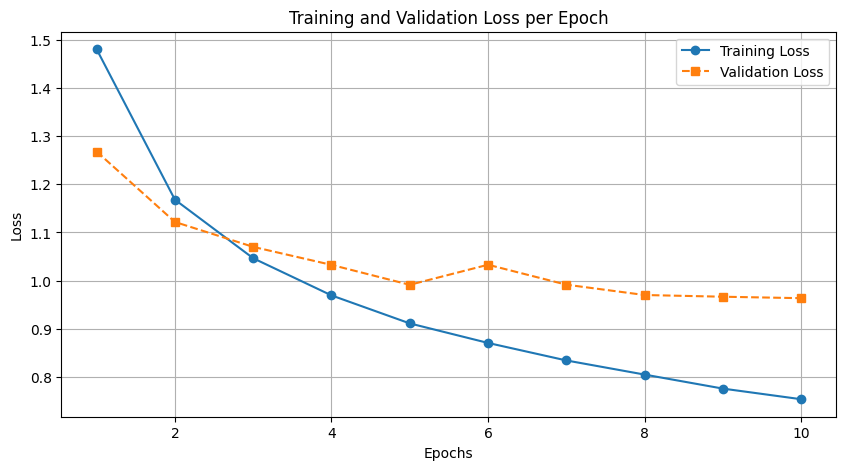

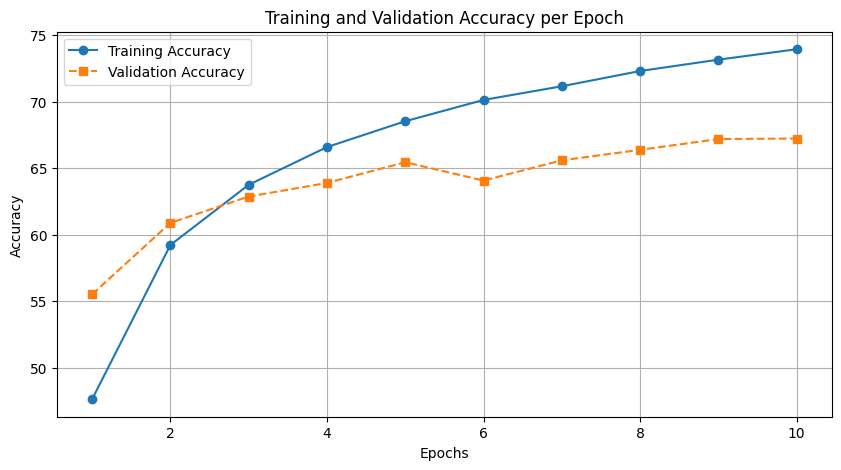

In [7]:
def plot_losses_and_accuracy(train_loss,train_acc,val_loss,val_acc):

  # Plot Loss
  plt.figure(figsize=(10, 5))
  plt.plot(range(1, num_epochs + 1), train_loss, label='Training Loss', marker='o')
  plt.plot(range(1, num_epochs + 1), val_loss, label='Validation Loss', marker='s', linestyle='--')
  plt.title('Training and Validation Loss per Epoch')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid()
  plt.show()

  # Plot Accuracy
  plt.figure(figsize=(10, 5))
  plt.plot(range(1, num_epochs + 1), train_acc, label='Training Accuracy', marker='o')
  plt.plot(range(1, num_epochs + 1), val_acc, label='Validation Accuracy', marker='s', linestyle='--')
  plt.title('Training and Validation Accuracy per Epoch')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid()
  plt.show()

plot_losses_and_accuracy(train_loss,train_acc,val_loss,val_acc)



## **Testing The Netwrok :**

In [8]:
def test_model(net, test_loader):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy of the best model on the 10000 test images: {100 * correct / total:.2f}%')



test_model(net, test_loader)


Accuracy of the best model on the 10000 test images: 67.89%


## **Visualize Feature Map:**

Now , we will choose a random image from the test set , push it through the model we trained and print the convolutional filters of the first layer after the training to see the features maps and visualize what the model learned on it .



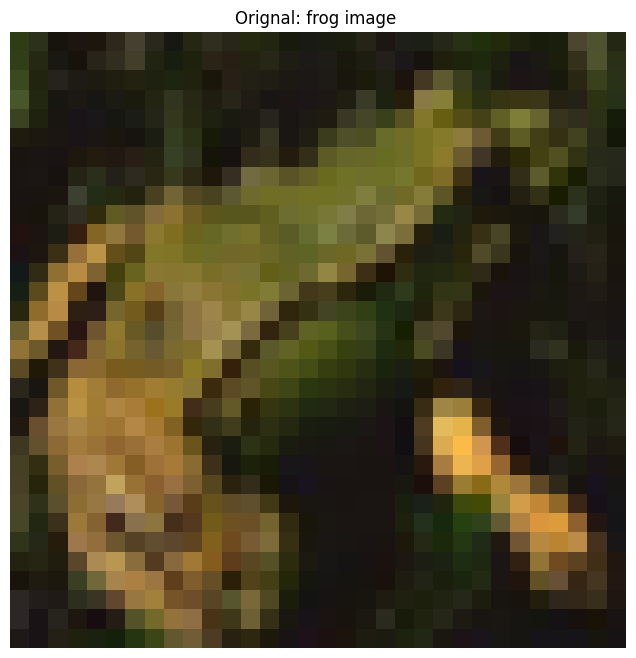

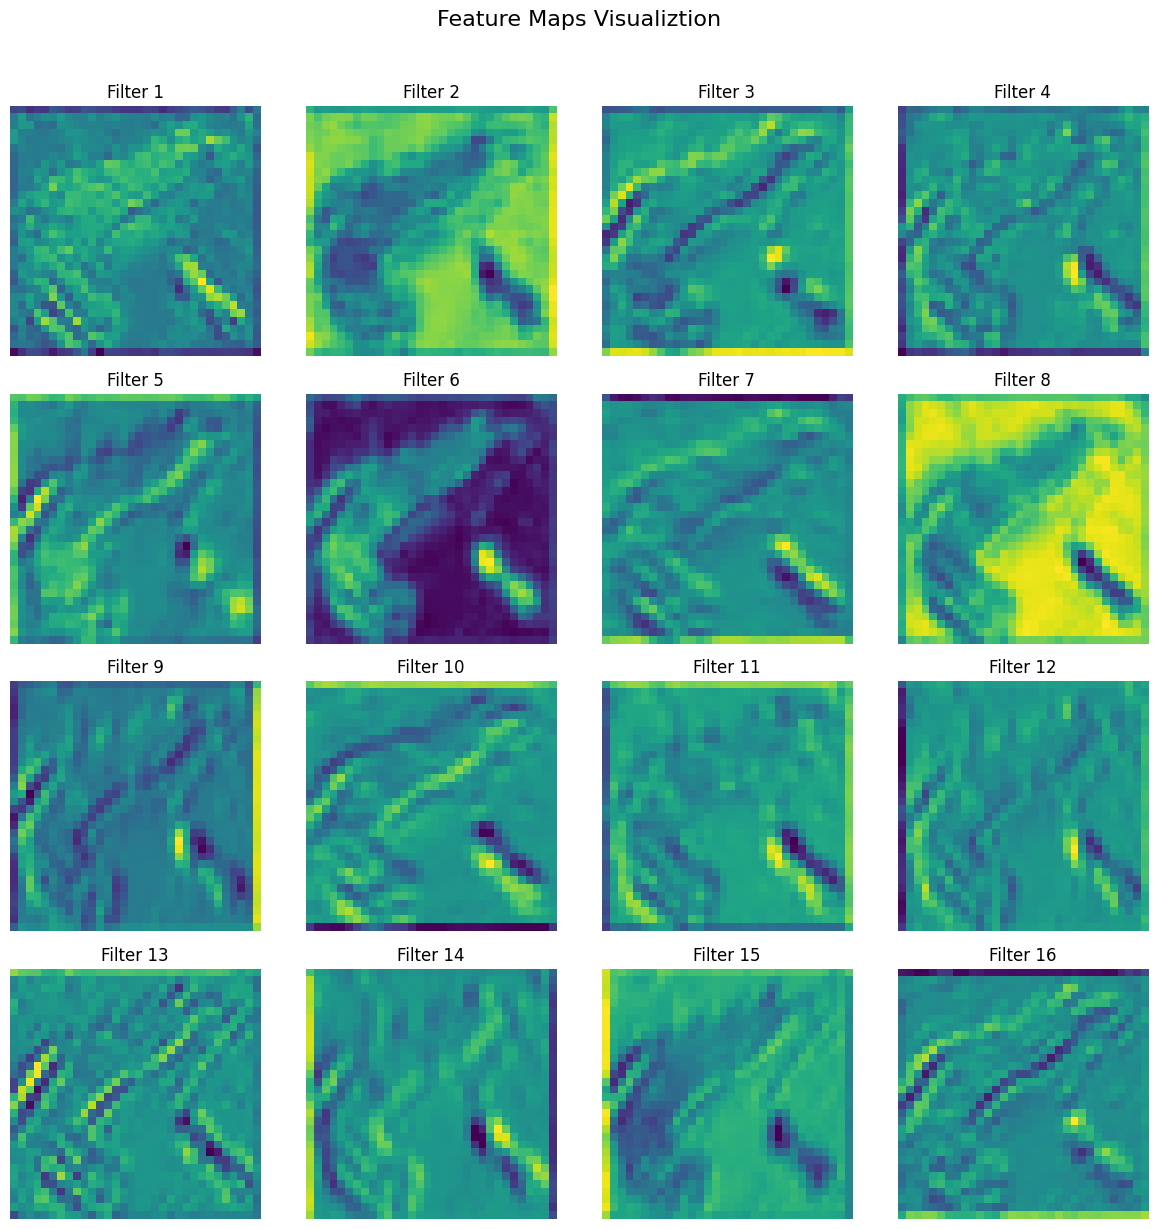

In [13]:
def show_feature_maps(net,label, test_loader):

  net.eval()

  # push the image through the first convlutional  layer
  with torch.no_grad():
    conv1_output=net.conv1(random_image)


  ## Visualize the orignal image
  plt.figure(figsize=(8,8))
  plt.imshow(imshow(random_image.squeeze()),interpolation='nearest')
  plt.title(f'Orignal: {classes[label]} image ')
  plt.axis('off')


  ## Visualize the feature map


  conv1_output=conv1_output.squeeze(0)
  filters_num=conv1_output.size(0)

  cols=4
  rows=(filters_num +cols -1)//cols



  fig,axes=plt.subplots(rows,cols,figsize=(12,12))
  fig.suptitle("Feature Maps Visualiztion", fontsize=16, y=1.02)

  axes=axes.flatten()

  for i in range(filters_num):

    ax=axes[i]
    ax.imshow(conv1_output[i].cpu().numpy(), cmap='viridis', interpolation='nearest')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

  plt.tight_layout()
  plt.show()



## Visualize fetaure maps for a random test image

# choose a random image from the test set

dataiter=iter(test_loader)
images, labels= next(dataiter)  # get a batch of test images
# pick an index for image randomly
idx=random.randint(0,len(images)-1)
random_image=images[idx].unsqueeze(0)
label=labels[idx]


show_feature_maps(net,label, test_loader)




# NETWORK 1 - Summary :

**Total num of parameters:**

input to conv layer 1 : 3 x 16 x (3x3) + 16 = 432 + 16 = 448. <br>
conv layer 1 to conv layer 2:  16 x 32 x (3x3) + 32 = 4608 + 32 = 4640. <br>
conv layer 2 to fcl:
input: 32 x 8 x 8 = 2048 ( flattened feature map size after pooling).<br>
output: 10 <br>
total 2048 x 10 + 10 = 20490.

**Total Parameters: 448 + 4640 + 20490 = 25578.**

In [14]:
# Print the network summary
print(net)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(net)

print(f'Total trainable parameters: {total_params}')

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=10, bias=True)
)
Total trainable parameters: 25578


## **TASK 2 :**

In this task we will define another CNN network with more depth of the network than the first CNN network from task 1


## **Define the architecture:**


*   **convlutional layers**:

  For all 4 convlutional layers we used :<br>
  Kernel size : 3x3 kernels. <br>
  Stride : 1.<br>
  padding : 1.<br>

1.   **Conv Layer 1 :**<br>
input : 3 channels (RGB image).<br>
output : 16 filters (feature maps).<br>

2.   **Conv Layer 2 :**<br>
input : 16 channels ( from conv1).<br>
output : 32 filters (feature maps).<br>


3.  **Conv Layer 3:**<br>
input : 32 channels ( output of conv2 ).<br>
output: 64 filters (feature maps).<br>


4.  **Conv Layer 4:**<br>
input : 64 channels ( output of conv3 ).<br>
output: 128 filters (feature maps).<br>





*   **Activation function :** ReLu for each convlutional layers.



*   **Pooling Layers:  :** Max Pooling layer after each ReLU-activated convlutional layer.

*    **Note:**  The feature maps output by the final polling layer are flattened into a 1D vector . So , we use this vector as the input to the last layer in the network (fully connected layer) .


  

*   **Fully Connected Layer :**<br>
the final layer is a fully connected layer :<br>
input 512 ( flattened feature vector) <br>
output : 10  ( one output for each CIFAR- 10 class).<br>










In [15]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # New layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # New layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated input size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))  # New layer
        x = self.pool(F.relu(self.conv4(x)))  # New layer
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


## **Training the Network:**

we will train the netwrok we build for 10 epochs with the same parameters from task 1:


1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:10.<br>
      Batch Size: 64.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.


In [16]:
net2 = DeepCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net2.parameters(), lr=0.001)

net2, train_loss2 , train_acc2 , val_loss2 , val_acc2 = train_and_validate(net2, criterion, optimizer, train_loader, val_loader)


Epoch 1/10 Loss: 1.593 Train Accuracy: 41.30% Validation Accuracy: 51.01%
Epoch 2/10 Loss: 1.231 Train Accuracy: 55.95% Validation Accuracy: 58.13%
Epoch 3/10 Loss: 1.059 Train Accuracy: 62.47% Validation Accuracy: 62.92%
Epoch 4/10 Loss: 0.937 Train Accuracy: 67.03% Validation Accuracy: 65.18%
Epoch 5/10 Loss: 0.837 Train Accuracy: 70.59% Validation Accuracy: 67.77%
Epoch 6/10 Loss: 0.757 Train Accuracy: 73.75% Validation Accuracy: 70.47%
Epoch 7/10 Loss: 0.686 Train Accuracy: 76.03% Validation Accuracy: 69.90%
Epoch 8/10 Loss: 0.616 Train Accuracy: 78.56% Validation Accuracy: 71.04%
Epoch 9/10 Loss: 0.566 Train Accuracy: 80.28% Validation Accuracy: 71.40%
Epoch 10/10 Loss: 0.515 Train Accuracy: 82.04% Validation Accuracy: 70.63%
Finished Training


# **Plot the losses and accuracy :**

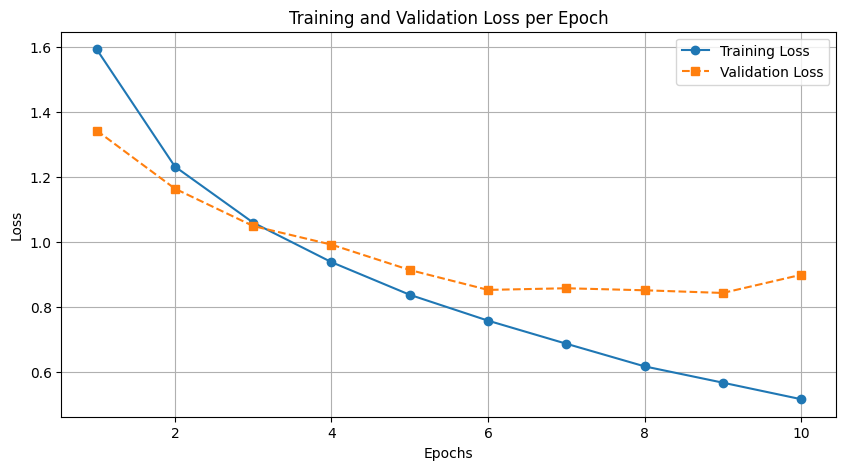

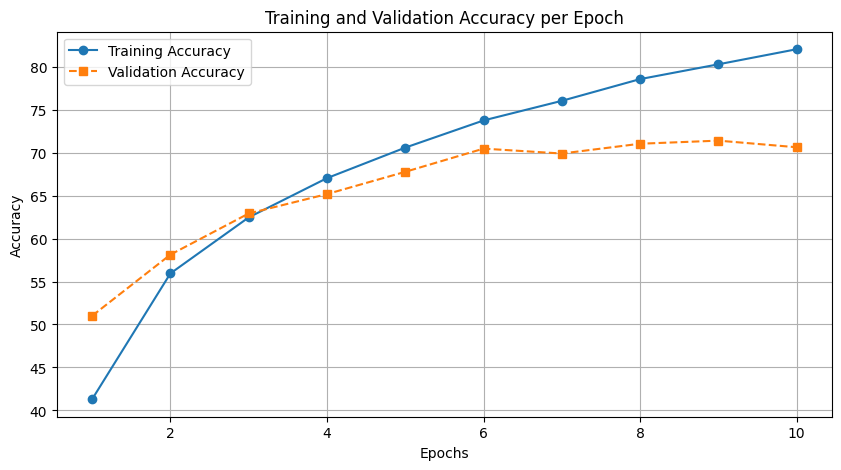

In [19]:
plot_losses_and_accuracy(train_loss2,train_acc2,val_loss2,val_acc2)

# Testing the Network

In [20]:
test_model(net2, test_loader)


Accuracy of the best model on the 10000 test images: 70.87%


# NETWORK 2 - Summary :

**Total num of parameters:**

input to conv layer 1 : 3 x 16 x (3x3) + 16 = 432 + 16 = 448. <br>
conv layer 1 to conv layer 2:  16 x 32 x (3x3) + 32 = 4608 + 32 = 4640. <br>
conv layer 2 to conv layer 3 : 32 x 64 x (3x3) + 64 = 18432 + 64 = 18496.<br>
conv layer 3 to conv layer 4 :  64 x 128 x (3x3) +  128 = 73728 + 128 = 73856. <br>
conv layer 4 to fcl:
input: 128 x 2 x 2 = 512 ( flattened feature map size after pooling).<br>
output: 10 <br>
total 512 x 10 + 10 = 5130.

**Total Parameters: 448 + 4640 + 18496 +73856  + 5130 = 102570.**

In [21]:

# Print the network summary
print(net2)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(net2)

print(f'Total trainable parameters: {total_params}')

DeepCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=512, out_features=10, bias=True)
)
Total trainable parameters: 102570


# **Comparison with the previous Network:**


From observing the result of the simple network of task 1 (SimpleCNN) and the results of the deeper network of task 2 (DeepCNN)  we can see :

1.   **SimpleCNN:**
*   SimpleCNN, with 2 convolutional layers , achieves a test accuracy of **(67.89%)**  after 10 epochs of training.
*   It trains quickly but shows signs of overfitting , as the  validation accuracy peaks at **(67.22%)**, while training accuracy reaches **(73.93%)**.
  

*   The training accuracy of **(73.93%)** compared to the validation accuracy of  **(67.22%)** highlights a gap that indicates limited generalization .


2.   **DeepCNN**:


*   DeepCNN, with 4 convolutional layers , achieves a higher test accuracy of **(70.87%)**
*   It generalizes better , with a validation accuracy of **(71.40%)** , due to its ability to learn more complex features from the deeper architecture .


*  The smaller gap between train  accuracy **(82.04%)** and validation accuracy **(71.40%)** indicate effective learning  with reduced overfitting.


*   Although it trains more slowly , it performs significantly  better in both accuracy and generalization .


So, although **SimpleCNN** is faster to train , **DeepCNN** is more effective with higher test accuracy for tasks that require higher accuracy like our classification task on CIFAR-10 Dataset.










## **TASK 3:**

In this task we will define another CNN network without the 2 layers we add in the previous task but with the some modifation from the network of task 1 :


## **Define the architecture:**


*   **convlutional layers**:

  For both convlutional layers we will use :<br>
  Kernel size : 5x5 kernels. <br>
  Stride : 2.<br>
  padding : 1.<br>

1.   **Conv Layer 1 :**<br>
input : 3 channels (RGB image).<br>
output : 16 filters (feature maps).<br>

2.   **Conv Layer 2 :**<br>
input : 16 channels ( from conv1).<br>
output : 32 filters (feature maps).<br>



*   **Activation function :** ReLu for both convlutional layers.



*   **Pooling Layers:  :** Max Pooling layer after each ReLU-activated convlutional layer.



*   **Fully Connected Layer :**<br>
 the final layer is a fully connected layer:<br>
input : 32 x 8 x 8 = 2048 ( flattened feature maps from conv2) <br>
output : 10  ( one output for each CIFAR- 10 class).<br>



In [22]:
class ModifiedCNN(nn.Module):
    def __init__(self):
        super(ModifiedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.fc1 = nn.Linear(32 * 2 * 2, 10)  # Adjusted based on new output size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


## **Training the Network:**

we will train the netwrok we build for 10 epochs with the same parameters from task 1:


1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:10.<br>
      Batch Size: 64.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.

In [23]:
net3 = ModifiedCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net3.parameters(), lr=0.001)

net3, train_loss3 , train_acc3 , val_loss3 , val_acc3 = train_and_validate(net3, criterion, optimizer, train_loader, val_loader)

Epoch 1/10 Loss: 1.646 Train Accuracy: 40.56% Validation Accuracy: 48.76%
Epoch 2/10 Loss: 1.351 Train Accuracy: 52.10% Validation Accuracy: 52.74%
Epoch 3/10 Loss: 1.255 Train Accuracy: 55.77% Validation Accuracy: 54.05%
Epoch 4/10 Loss: 1.187 Train Accuracy: 58.41% Validation Accuracy: 55.94%
Epoch 5/10 Loss: 1.131 Train Accuracy: 60.45% Validation Accuracy: 58.00%
Epoch 6/10 Loss: 1.091 Train Accuracy: 61.93% Validation Accuracy: 59.56%
Epoch 7/10 Loss: 1.053 Train Accuracy: 63.27% Validation Accuracy: 59.49%
Epoch 8/10 Loss: 1.020 Train Accuracy: 64.28% Validation Accuracy: 60.49%
Epoch 9/10 Loss: 0.999 Train Accuracy: 65.33% Validation Accuracy: 61.50%
Epoch 10/10 Loss: 0.975 Train Accuracy: 65.98% Validation Accuracy: 59.82%
Finished Training


# **Plot the losses and accuracy :**

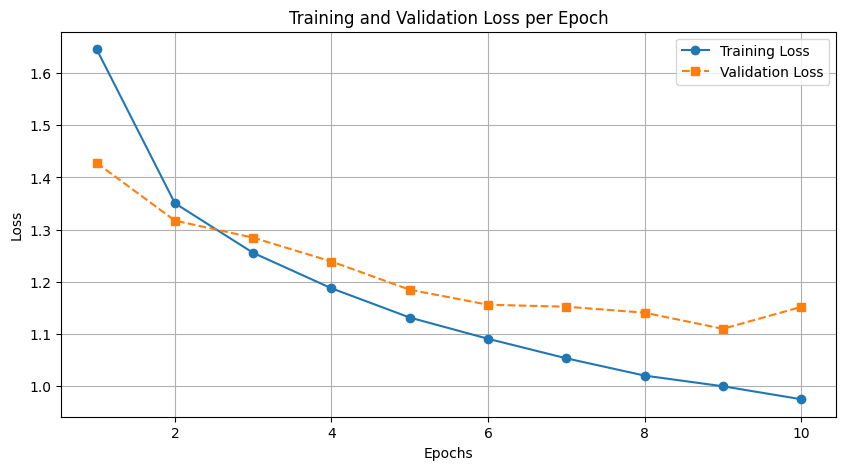

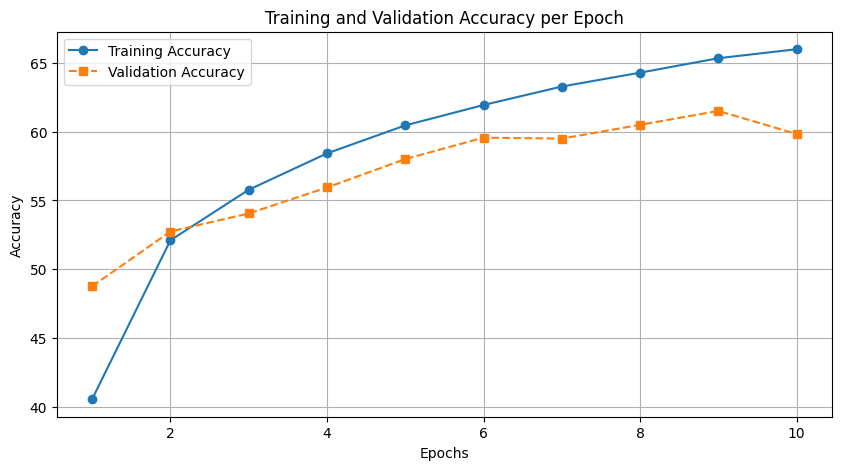

In [24]:
plot_losses_and_accuracy(train_loss3,train_acc3,val_loss3,val_acc3)

# Testing the Network

In [25]:
test_model(net3, test_loader)


Accuracy of the best model on the 10000 test images: 60.29%


# **Comparison with the previous Networks:**

**We will compare between the results of the simple network of Task 1 and the deeper network of task 2 with the current network we build:**

We can see  that the modified network **(ModifiedCNN)** in this task with 2 convolutional layers , but with updated kernel size and stride :<br>

*    Achieves the lowest test accuracy **(60.29%)** among all the three network we trained so far .
*   
Although , it trains steadily but achieves lower training **(65.98%)** and validation **(59.82%)** accuracies compared to the previous two networks .



*    We can see a large gap between training and validation accuracy **(65.98% vs. 59.82%)** which indicates limited generalization .
*   **Why this happening  ?** <br>
The architecture of the ModifiedCNN network , with larger kernel sizes and strides , although it simplify the computations but in the same time it reduces the network ability to learn detailed features , leading to lower accuracy.




## **Visualize Feature Map:**

Now , we will use the random image from the test set that we chose in task 1 , push it through the model we trained  in this task and print the convolutional filters of the first layer after the training to see the features maps and visualize what the model learned on it .


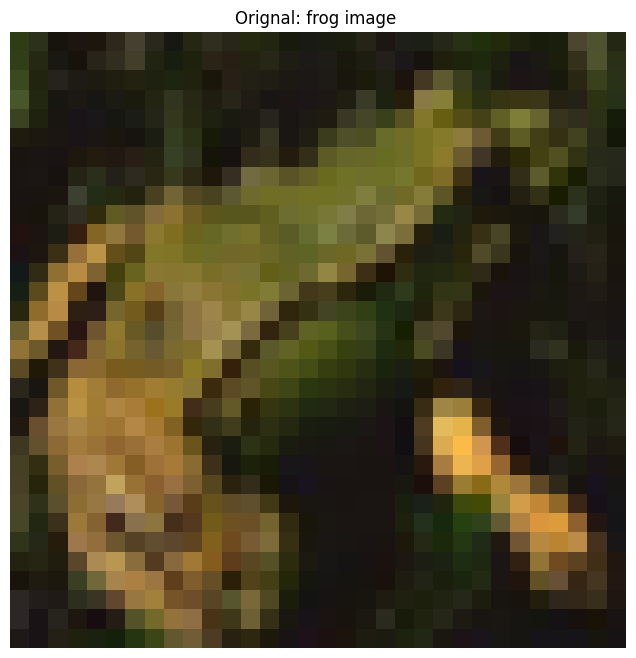

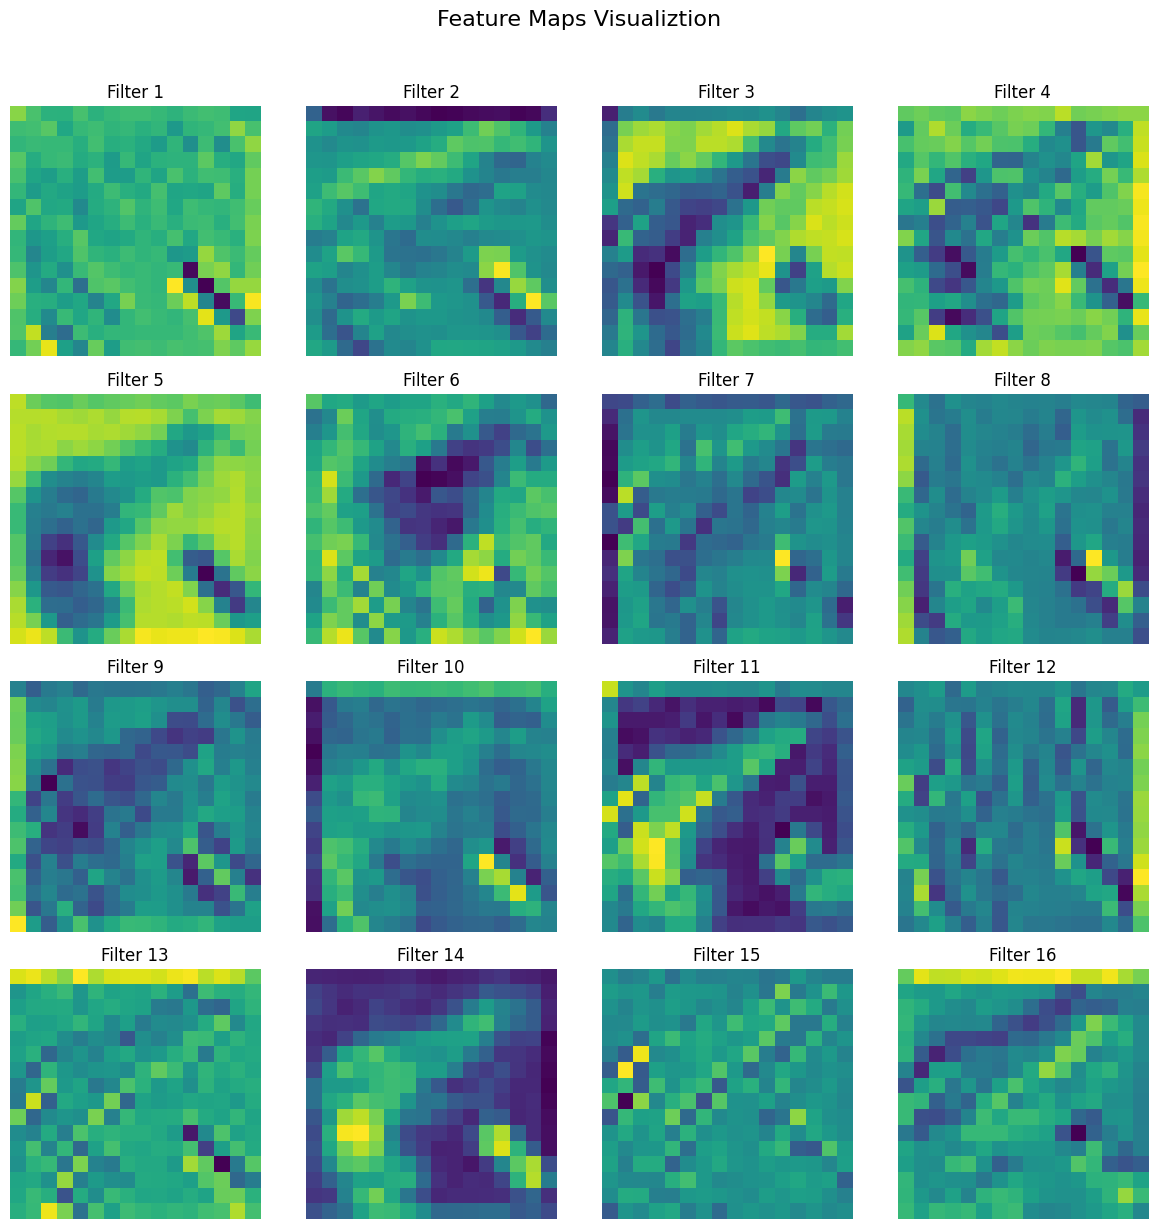

In [26]:
show_feature_maps(net3,label, test_loader)

# **Note:**

If we compare the feature maps of the current network with the feature map of the network of task 1 :<br>
we can see the next notable differences how each network extract and process features : <br>


*    The **SimpleCNN's** feature maps show a higher level of detail with small patterns saved . due to , its smaller kernel size and stride , which allow it to retain more spatial information .
*    In contrast , the **ModifiedCNN's** feature maps show less detail and extended feature representation . due to ,as we explained before ,its larger kernel size and stride that lead to more aggressive down- sampling .


 all of this explain why we get lower accuracy for the  ModifiedCNN network .

# NETWORK 3 - Summary :

**Total num of parameters:**

input to conv layer 1 : 3 x 16 x (5x5) + 16 = 1200 + 16 = 1216. <br>
conv layer 1 to conv layer 2:  16 x 32 x (5x5) + 32 = 12800 + 32 = 12832. <br>
conv layer 2 to fcl:
input: 32 x 2 x 2 = 2048 ( flattened feature map size after pooling).<br>
output: 10 <br>
total 128 x 10 + 10 = 1290.

**Total Parameters: 1216 + 12832 + 1290 = 15338.**

In [27]:

# Print the network summary
print(net3)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(net3)

print(f'Total trainable parameters: {total_params}')

ModifiedCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (fc1): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 15338


## **TASK 4 :**

In this task we will define another CNN network with the same architecture of the best network so far , but instead of using Max pooling we will use average pooling.

because we get the best acuuracy values **( acuuracy=  70.87%)** for the network of task 2 , so will use the same architecture of it with average pooling.



In [28]:
class DeepCNN_AvgPool(nn.Module):
    def __init__(self):
        super(DeepCNN_AvgPool, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # Changed to Average Pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated for additional layers

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


## **Training the Network:**

we will train the netwrok we build for 10 epochs with the same parameters from task 1:


1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:10.<br>
      Batch Size: 64.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.

In [29]:
net4 = DeepCNN_AvgPool()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net4.parameters(), lr=0.001)

net4, train_loss4 , train_acc4 , val_loss4 , val_acc4, = train_and_validate(net4, criterion, optimizer, train_loader, val_loader)

Epoch 1/10 Loss: 1.727 Train Accuracy: 36.83% Validation Accuracy: 45.41%
Epoch 2/10 Loss: 1.417 Train Accuracy: 48.88% Validation Accuracy: 48.77%
Epoch 3/10 Loss: 1.276 Train Accuracy: 54.18% Validation Accuracy: 54.80%
Epoch 4/10 Loss: 1.163 Train Accuracy: 58.23% Validation Accuracy: 58.44%
Epoch 5/10 Loss: 1.084 Train Accuracy: 61.60% Validation Accuracy: 60.52%
Epoch 6/10 Loss: 1.013 Train Accuracy: 64.24% Validation Accuracy: 61.33%
Epoch 7/10 Loss: 0.956 Train Accuracy: 66.23% Validation Accuracy: 63.53%
Epoch 8/10 Loss: 0.902 Train Accuracy: 68.14% Validation Accuracy: 63.88%
Epoch 9/10 Loss: 0.850 Train Accuracy: 70.10% Validation Accuracy: 66.62%
Epoch 10/10 Loss: 0.810 Train Accuracy: 71.48% Validation Accuracy: 66.71%
Finished Training


# **Plot the losses and accuracy :**

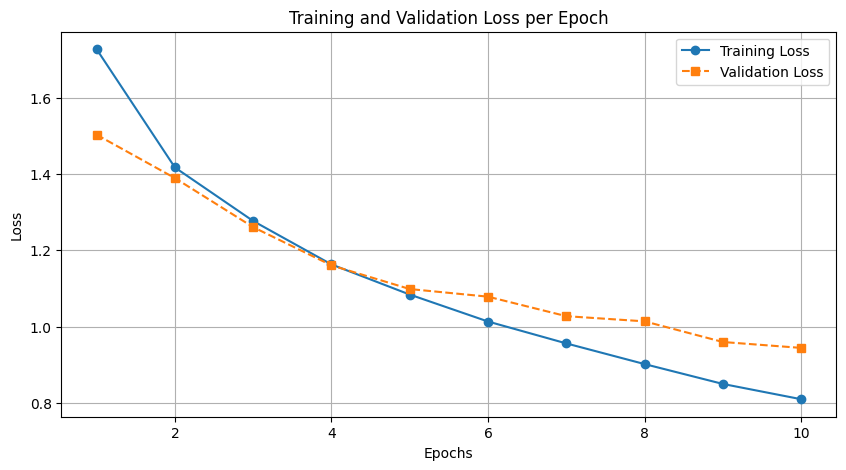

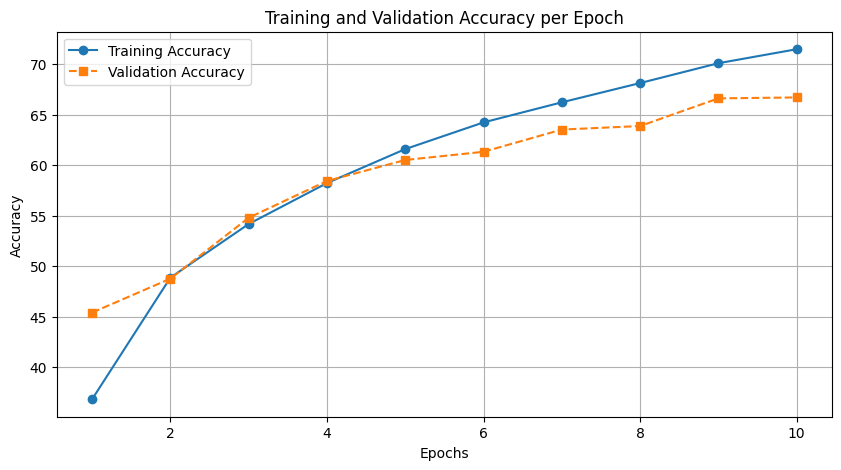

In [30]:
plot_losses_and_accuracy(train_loss4,train_acc4,val_loss4,val_acc4)

# Testing the Network

In [31]:
test_model(net4, test_loader)

Accuracy of the best model on the 10000 test images: 67.07%


# NETWORK 4 - Summary :

The total number of parameters will remain the same as the total number of parameters of network 2 form task 2. because ,we only change the pooling method and use the same architecture . <br> <br>

**Total Parameters: 102570.**


In [32]:

# Print the network summary
print(net4)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(net4)

print(f'Total trainable parameters: {total_params}')

DeepCNN_AvgPool(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=512, out_features=10, bias=True)
)
Total trainable parameters: 102570


# Comapring between Network of Task 4 with the best network :

we can see that current network, which has the same architecture as the DeepCNN network ( that reached the best accuracy result) but with using average pooling instead of max pooling :


*   Ahieves a lower test accuracy **(67.07%)** compared to the DeepCNN's **(70.87%)** (note: the current network achieves higher accuracy result than the rest two network)
*   
Validation accuracy peaks at **(66.71%)** , which indicate less generalization compared to DeepCNN , which peaks at **(71.40%)**.





*   **why ?**<br>
  Using **max pooling** helps the network to capture more dominant feature , such as edges or sharp variations , which are important for classification tasks.

  In Contract , using **average pooling** smooths the feature maps by averaging  leading to a loss of important high-frequency details , making it less effective for classification task .












